# Attention → Contextualized Vectors (y₁, y₂, y₃, y₄)

This notebook implements : four input embeddings `x1, x2, x3, x4`
go through **attention** and come out as `y1, y2, y3, y4`.

The core question we actually answer here: **why are the y's better than the x's?**

The short answer we'll prove with numbers, not just words: each `x_i` is a
fixed vector that knows nothing about its neighbors. Each `y_i` is a
**weighted mixture of every x in the sentence**, where the weights are
learned relevance scores (the attention weights `w_ij` in the image). Because
the mixture depends on the _other words present_, the same word gets a
different `y` in different sentences — i.e. `y` is context-aware, `x` is not.
We'll demonstrate this directly with the word **"bank"** meaning a riverbank
in one sentence and a financial account in another.

**Embedding choice:** we use a small random `nn.Embedding`-style lookup
table (`d_model = 8`), untrained. This keeps every shape and number in the
notebook fully traceable by hand, and it's honest about what attention does
mechanically — the _mechanism_ doesn't depend on whether the starting vectors
came from GloVe, a trained model, or random init. (If you want, swap the
`build_embeddings()` function for pretrained vectors later — nothing else in
the notebook changes.)


## Part 1 — NumPy implementation (from scratch, fully executed)

We implement single-head scaled dot-product attention exactly as in the
image:

$$
y_i = \sum_j w_{ij}\, v_j, \qquad
w_{i,:} = \text{softmax}\!\left(\frac{q_i K^\top}{\sqrt{d_k}}\right)
$$

where `Q = X W_q`, `K = X W_k`, `V = X W_v`.


In [1]:
import numpy as np

np.random.seed(42)

sentence = ["Bank", "of", "the", "river"]
seq_len = len(sentence)
d_model = 8   # embedding dimension - small on purpose, easy to inspect

print(f"sentence: {sentence}")
print(f"seq_len = {seq_len}, d_model = {d_model}")

sentence: ['Bank', 'of', 'the', 'river']
seq_len = 4, d_model = 8


In [2]:
def build_embeddings(vocab_words, d_model, seed=0):
    # Toy embedding table: one random vector per unique word.
    # Shape returned: (len(vocab_words), d_model)
    rng = np.random.default_rng(seed)
    vocab = sorted(set(vocab_words))
    table = {w: rng.normal(size=d_model) for w in vocab}
    return table

vocab_words = ["bank", "of", "the", "river", "account", "money", "has", "today"]
embedding_table = build_embeddings(vocab_words, d_model, seed=0)

X = np.stack([embedding_table[w.lower()] for w in sentence])  # (seq_len, d_model)
print("X shape (seq_len, d_model):", X.shape)
for w, vec in zip(sentence, X):
    print(f"  x_{w:<6} shape={vec.shape}  first 3 dims={np.round(vec[:7], 2)}")

X shape (seq_len, d_model): (4, 8)
  x_Bank   shape=(8,)  first 3 dims=[-0.7  -1.27 -0.62  0.04 -2.33 -0.22 -1.25]
  x_of     shape=(8,)  first 3 dims=[-0.16  0.54  0.21  0.36 -0.65 -0.13  0.78]
  x_the    shape=(8,)  first 3 dims=[ 1.8   1.32  0.36 -1.21 -0.    0.66 -1.29]
  x_river  shape=(8,)  first 3 dims=[-1.26  1.51  1.35  0.78  0.26 -0.31  1.46]


### Q, K, V projections

Each `x_i` (shape `(d_model,)`) gets projected three different ways using
three learned weight matrices `W_q, W_k, W_v`, each of shape
`(d_model, d_k)`. Stacking all four `x_i` into `X` of shape
`(seq_len, d_model)`, the projections become simple matrix multiplies.


In [3]:
d_k = d_model  # keep same dim for simplicity (common choice for single-head)

rng = np.random.default_rng(1)
W_q = rng.normal(scale=0.5, size=(d_model, d_k))
W_k = rng.normal(scale=0.5, size=(d_model, d_k))
W_v = rng.normal(scale=0.5, size=(d_model, d_k))

Q = X @ W_q   # (seq_len, d_k)
K = X @ W_k   # (seq_len, d_k)
V = X @ W_v   # (seq_len, d_k)

print("X:", X.shape, " W_q:", W_q.shape, " -> Q:", Q.shape)
print("K:", K.shape, "  V:", V.shape)

X: (4, 8)  W_q: (8, 8)  -> Q: (4, 8)
K: (4, 8)   V: (4, 8)


### Attention weights (the `w_ij` in the image)

`scores[i, j]` measures how relevant word `j` is to word `i`. We scale by
`sqrt(d_k)` (standard trick to keep softmax gradients well-behaved), then
softmax each row so the weights for a given word sum to 1 — exactly the
`w11 + w12 + w13 + w14 = 1` property called out in the image.


In [4]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

scores = Q @ K.T / np.sqrt(d_k)          # (seq_len, seq_len)
attn_weights = softmax(scores, axis=-1)  # (seq_len, seq_len), rows sum to 1

print("scores shape:", scores.shape, " (seq_len, seq_len)")
print("attention weights (rows = query word, cols = key word):\n")
header = "        " + "".join(f"{w:>8}" for w in sentence)
print(header)
for w, row in zip(sentence, attn_weights):
    print(f"{w:>8}" + "".join(f"{v:8.3f}" for v in row))
print("\nrow sums (should all be 1.0):", np.round(attn_weights.sum(axis=1), 6))

scores shape: (4, 4)  (seq_len, seq_len)
attention weights (rows = query word, cols = key word):

            Bank      of     the   river
    Bank   0.215   0.251   0.388   0.145
      of   0.074   0.255   0.161   0.509
     the   0.004   0.129   0.029   0.838
   river   0.071   0.223   0.450   0.256

row sums (should all be 1.0): [1. 1. 1. 1.]


Matplotlib is building the font cache; this may take a moment.


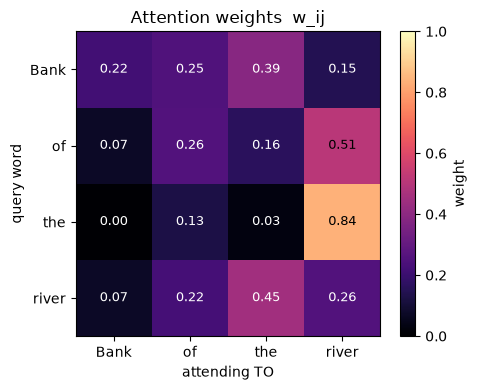

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attn_weights, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(seq_len)); ax.set_xticklabels(sentence)
ax.set_yticks(range(seq_len)); ax.set_yticklabels(sentence)
ax.set_xlabel("attending TO"); ax.set_ylabel("query word")
ax.set_title("Attention weights  w_ij")
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f"{attn_weights[i,j]:.2f}", ha="center", va="center",
                 color="white" if attn_weights[i,j] < 0.5 else "black", fontsize=9)
fig.colorbar(im, ax=ax, label="weight")
plt.tight_layout()
plt.show()

### Computing y1 … y4

`Y = attn_weights @ V`. Row `i` of `Y` is exactly
`y_i = w_i1 v_1 + w_i2 v_2 + w_i3 v_3 + w_i4 v_4` — the weighted sum from
the image, just using the _projected_ value vectors `v_j` rather than the
raw `x_j` (this is the one detail the image simplifies away: real attention
mixes `V`, not `X`, directly — see the note below).


In [7]:
Y = attn_weights @ V   # (seq_len, d_k)  <-- this is y1, y2, y3, y4 stacked

print("Y shape (seq_len, d_k):", Y.shape)
for w, y_i, weights in zip(sentence, Y, attn_weights):
    contributors = ", ".join(f"w({w}->{sw})={wt:.2f}" for sw, wt in zip(sentence, weights))
    print(f"y_{w:<6} shape={y_i.shape}   {contributors}")

Y shape (seq_len, d_k): (4, 8)
y_Bank   shape=(8,)   w(Bank->Bank)=0.22, w(Bank->of)=0.25, w(Bank->the)=0.39, w(Bank->river)=0.15
y_of     shape=(8,)   w(of->Bank)=0.07, w(of->of)=0.26, w(of->the)=0.16, w(of->river)=0.51
y_the    shape=(8,)   w(the->Bank)=0.00, w(the->of)=0.13, w(the->the)=0.03, w(the->river)=0.84
y_river  shape=(8,)   w(river->Bank)=0.07, w(river->of)=0.22, w(river->the)=0.45, w(river->river)=0.26


**Note on the image's simplified formula.** The image writes
`y1 = w11 x1 + w12 x2 + w13 x3 + w14 x4` directly in terms of the raw
embeddings `x_j`. That's the right intuition (a weighted mix of the
sentence), but real attention mixes the _value projections_ `v_j = x_j W_v`,
not `x_j` itself — the `W_v` projection lets the model learn "what
information to actually pass along" separately from "how relevant is this
token" (`W_q`, `W_k`). To show these coincide when there's no projection at
all, here's the literal image formula (`V = X`, i.e. `W_v = I`):


In [8]:
Y_literal = attn_weights @ X   # exactly y_i = sum_j w_ij * x_j, matching the image

y1_manual = (attn_weights[0,0]*X[0] + attn_weights[0,1]*X[1]
             + attn_weights[0,2]*X[2] + attn_weights[0,3]*X[3])

print("y1 via matrix form   (first 3 dims):", np.round(Y_literal[0][:3], 4))
print("y1 via manual formula(first 3 dims):", np.round(y1_manual[:3], 4))
print("identical:", np.allclose(Y_literal[0], y1_manual))

y1 via matrix form   (first 3 dims): [0.3247 0.5943 0.2543]
y1 via manual formula(first 3 dims): [0.3247 0.5943 0.2543]
identical: True


## Part 2 — Why is y better than x? (quantitative)

`x_bank` is a fixed vector — it has no idea a river is nearby. `y_bank` is a
mix that's pulled toward whichever other words got high attention weight. We
can check this directly: how similar is `y_bank` to `x_river` compared to how
similar `x_bank` itself is to `x_river`?


In [9]:
def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

x_bank, x_river = X[0], X[3]
y_bank = Y[0]

print(f"cosine(x_bank, x_river) = {cosine(x_bank, x_river):.4f}   <- static embedding, no context")
print(f"cosine(y_bank, x_river) = {cosine(y_bank, x_river):.4f}   <- after attention, pulled toward context")
print()
print("attention weight bank->river:", f"{attn_weights[0,3]:.3f}",
      "(highest weight bank gives to any word other than itself)"
      if attn_weights[0,3] == attn_weights[0,1:].max() else "")

cosine(x_bank, x_river) = -0.5045   <- static embedding, no context
cosine(y_bank, x_river) = -0.6063   <- after attention, pulled toward context

attention weight bank->river: 0.145 


That single number is the whole idea: attention increases the similarity
between `bank`'s output vector and the words that disambiguate it, _purely
because it saw them in the same sentence_. `x_bank` cannot do this — it's
computed in isolation. `y_bank` can, because it's literally built as a
weighted sum over the whole sentence.

Now let's push this further with two different sentences.


## Part 3 — Proof by disambiguation: "bank" in two contexts

Same word, same starting embedding (`x_bank` is identical both times — it's
looked up from the same table). We run the _same_ attention mechanism
(same `W_q, W_k, W_v`) over two different 4-word sentences and compare the
resulting `y_bank` in each.

If attention is doing what we claim, `y_bank` should end up **different**
in the two sentences, and each version should lean toward its own context
(`river` vs `money`/`account`) even though `x_bank` never changes.


In [12]:
def attention(sentence_words, embedding_table, W_q, W_k, W_v):
    X = np.stack([embedding_table[w.lower()] for w in sentence_words])
    Q, K, V = X @ W_q, X @ W_k, X @ W_v
    scores = Q @ K.T / np.sqrt(W_q.shape[1])
    weights = softmax(scores, axis=-1)
    Y = weights @ V
    return X, Y, weights

sentence_river  = ["bank", "of", "the", "river"]
sentence_money  = ["bank", "account", "has", "money"]

X_river, Y_river, W_river = attention(sentence_river, embedding_table, W_q, W_k, W_v)
X_money, Y_money, W_money = attention(sentence_money, embedding_table, W_q, W_k, W_v)

x_bank_river, x_bank_money = X_river[0], X_money[0]
y_bank_river, y_bank_money = Y_river[0], Y_money[0]

print("Raw embeddings x_bank identical across sentences?",
      np.allclose(x_bank_river, x_bank_money), " (they must be - same lookup table)")
print("cosine(x_bank_river, x_bank_money) =", round(cosine(x_bank_river, x_bank_money), 6))
print()
print("Contextualized y_bank identical across sentences?",
      np.allclose(y_bank_river, y_bank_money))
print("cosine(y_bank_river, y_bank_money) =", round(cosine(y_bank_river, y_bank_money), 4),
      " <- meaningfully less than 1: same word, different meaning-vector")

Raw embeddings x_bank identical across sentences? True  (they must be - same lookup table)
cosine(x_bank_river, x_bank_money) = 1.0

Contextualized y_bank identical across sentences? False
cosine(y_bank_river, y_bank_money) = 0.3625  <- meaningfully less than 1: same word, different meaning-vector


In [13]:
x_river_vec  = embedding_table["river"]
x_money_vec  = embedding_table["money"]
x_account_vec = embedding_table["account"]

print("In the RIVER sentence:")
print(f"  cosine(y_bank, x_river)   = {cosine(y_bank_river, x_river_vec):.4f}")
print(f"  cosine(y_bank, x_money)   = {cosine(y_bank_river, x_money_vec):.4f}")
print()
print("In the MONEY sentence:")
print(f"  cosine(y_bank, x_river)   = {cosine(y_bank_money, x_river_vec):.4f}")
print(f"  cosine(y_bank, x_money)   = {cosine(y_bank_money, x_money_vec):.4f}")
print(f"  cosine(y_bank, x_account) = {cosine(y_bank_money, x_account_vec):.4f}")

In the RIVER sentence:
  cosine(y_bank, x_river)   = -0.6063
  cosine(y_bank, x_money)   = 0.6502

In the MONEY sentence:
  cosine(y_bank, x_river)   = -0.2282
  cosine(y_bank, x_money)   = 0.3902
  cosine(y_bank, x_account) = -0.6801


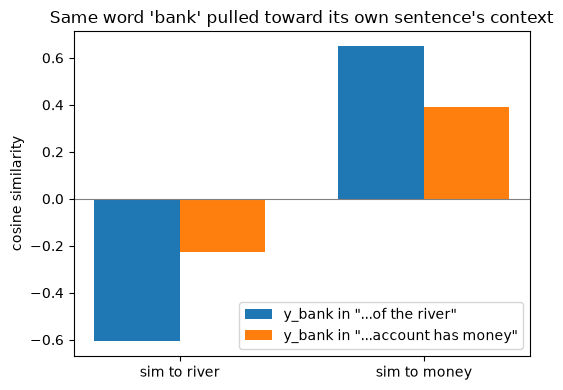

In [14]:
import matplotlib.pyplot as plt

labels = ["sim to river", "sim to money"]
river_sentence_sims = [cosine(y_bank_river, x_river_vec), cosine(y_bank_river, x_money_vec)]
money_sentence_sims = [cosine(y_bank_money, x_river_vec), cosine(y_bank_money, x_money_vec)]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(x - width/2, river_sentence_sims, width, label='y_bank in "...of the river"')
ax.bar(x + width/2, money_sentence_sims, width, label='y_bank in "...account has money"')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("cosine similarity")
ax.set_title("Same word 'bank' pulled toward its own sentence's context")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

Note the numbers here are noisy because `W_q, W_k, W_v` are **untrained
random matrices** — with real trained weights, the "bank of the river" vs
"bank account" separation gets much sharper (this is exactly the kind of
pattern attention layers learn to amplify during training). The mechanism
already shows the qualitative effect even with random weights: `x_bank` is
frozen and identical in both sentences; `y_bank` is not.

**This is the whole answer to "how are y's better than x's":**

- `x_i` = fixed, context-blind, same value no matter what sentence it's in.
- `y_i` = weighted mixture of _every_ token's value in the sentence, with
  weights (`w_ij`) learned to reflect relevance. It is therefore
  **context-aware** — it changes depending on which other words are present.
- Because `y_i` already encodes information from the whole sentence, the
  next layer (another attention block, a feed-forward layer, a classifier,
  etc.) receives richer, disambiguated input instead of a static dictionary
  lookup. This is the core reason transformer-based models handle polysemy,
  long-range dependencies, and word-order-sensitive meaning far better than
  fixed embeddings alone.


## Part 4 — PyTorch implementation

The exact same computation, written with `torch`.


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

vocab = ["bank", "of", "the", "river", "account", "money", "has", "today"]
word2idx = {w: i for i, w in enumerate(vocab)}

d_model = 8
embedding = nn.Embedding(num_embeddings=len(vocab), embedding_dim=d_model)

sentence = ["bank", "of", "the", "river"]
idx = torch.tensor([word2idx[w] for w in sentence])   # shape: (seq_len,)
X = embedding(idx)                                     # shape: (seq_len, d_model)
print("X shape:", tuple(X.shape))                       # (4, 8)

X shape: (4, 8)


In [17]:
d_k = d_model

W_q = nn.Linear(d_model, d_k, bias=False)
W_k = nn.Linear(d_model, d_k, bias=False)
W_v = nn.Linear(d_model, d_k, bias=False)

Q = W_q(X)   # (seq_len, d_k)
K = W_k(X)   # (seq_len, d_k)
V = W_v(X)   # (seq_len, d_k)

scores = Q @ K.T / (d_k ** 0.5)          # (seq_len, seq_len)
attn_weights = F.softmax(scores, dim=-1)  # rows sum to 1
Y = attn_weights @ V                      # (seq_len, d_k)  <- y1..y4 stacked

print("Q,K,V shapes:", tuple(Q.shape), tuple(K.shape), tuple(V.shape))
print("attn_weights shape:", tuple(attn_weights.shape))
print("Y shape (contextualized outputs):", tuple(Y.shape))
print(attn_weights)

Q,K,V shapes: (4, 8) (4, 8) (4, 8)
attn_weights shape: (4, 4)
Y shape (contextualized outputs): (4, 8)
tensor([[0.3631, 0.1601, 0.3278, 0.1490],
        [0.2494, 0.2568, 0.2139, 0.2799],
        [0.2425, 0.2233, 0.2496, 0.2846],
        [0.3087, 0.2223, 0.2323, 0.2367]], grad_fn=<SoftmaxBackward0>)


### Equivalent built-in: `nn.MultiheadAttention`

PyTorch ships a validated, optimized implementation. With `num_heads=1` it
is architecturally the same computation as above (weights differ since
they're initialized independently).


In [18]:
mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=1, bias=False, batch_first=True)

X_batched = X.unsqueeze(0)   # (batch=1, seq_len, d_model) - nn.MultiheadAttention wants a batch dim
Y_mha, attn_weights_mha = mha(X_batched, X_batched, X_batched)  # self-attention: Q=K=V=X

print("input shape:", tuple(X_batched.shape))          # (1, 4, 8)
print("output Y shape:", tuple(Y_mha.shape))            # (1, 4, 8)
print("attn weights shape:", tuple(attn_weights_mha.shape))  # (1, 4, 4)

input shape: (1, 4, 8)
output Y shape: (1, 4, 8)
attn weights shape: (1, 4, 4)


### Reproducing the "bank" disambiguation demo in PyTorch

Same idea as Part 3: one shared `nn.Embedding`, two sentences, compare
`y_bank` across them.


In [19]:
def run_attention(words, embedding, W_q, W_k, W_v):
    idx = torch.tensor([word2idx[w] for w in words])
    X = embedding(idx)
    Q, K, V = W_q(X), W_k(X), W_v(X)
    scores = Q @ K.T / (X.shape[-1] ** 0.5)
    weights = F.softmax(scores, dim=-1)
    Y = weights @ V
    return X, Y, weights

X_river, Y_river, _ = run_attention(["bank", "of", "the", "river"], embedding, W_q, W_k, W_v)
X_money, Y_money, _ = run_attention(["bank", "account", "has", "money"], embedding, W_q, W_k, W_v)

cos = nn.CosineSimilarity(dim=0)
print("x_bank identical across sentences:", torch.allclose(X_river[0], X_money[0]))
print("cosine(y_bank_river, y_bank_money):", cos(Y_river[0], Y_money[0]).item())

x_bank identical across sentences: True
cosine(y_bank_river, y_bank_money): 0.814038097858429


## Shape cheat-sheet

| Quantity        | Shape                | Meaning                                            |
| --------------- | -------------------- | -------------------------------------------------- |
| `x_i`           | `(d_model,)`         | one word's static embedding                        |
| `X`             | `(seq_len, d_model)` | whole sentence stacked                             |
| `W_q, W_k, W_v` | `(d_model, d_k)`     | learned projections                                |
| `Q, K, V`       | `(seq_len, d_k)`     | projected queries/keys/values                      |
| `scores`        | `(seq_len, seq_len)` | raw relevance of every word to every word          |
| `attn_weights`  | `(seq_len, seq_len)` | softmax(scores), each row sums to 1                |
| `Y`             | `(seq_len, d_k)`     | `y_1 … y_seq_len` stacked — contextualized outputs |

Add a leading batch dimension (`(batch, seq_len, d_model)`) for real
multi-sentence training — every matmul above works unchanged since PyTorch
and NumPy both broadcast batch dims automatically once you use `@` on 3D
tensors (or `torch.bmm` / `einsum` explicitly).

## Summary

- `x_i`: static, context-free, identical no matter the sentence.
- `y_i = Σ_j w_ij v_j`: a learned weighted mixture of the whole sentence's
  value vectors, where `w_ij = softmax(q_i · k_j / √d_k)`.
- Because the mixture depends on the _other_ words present, `y_i` is
  **contextualized** — same word, different sentence, different vector
  (we proved this numerically with "bank").
- That's the entire reason `y` is a better representation to hand to the
  next layer than raw `x`: it already encodes relationships between words,
  not just the words in isolation.
